# Customer Segmentation using RFM + KMeans
# Dataset: Online Retail
# Goal: Segment customers into VIP / Regular / Inactive



Steps:
1. Import libraries
2. Load dataset
3. Data cleaning
4. Feature engineering
5. EDA
6. RFM calculation
7. Scaling
8. Elbow Method
9. KMeans clustering
10. Cluster evaluation (Silhouette Score)
11. Cluster visualization
12. Cluster naming
13. Merge with original data
14. Product analysis per cluster
15. Save output


In [30]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load dataset
df = pd.read_csv('../Dataset/RAW/online_retail.csv', encoding='latin-1')

# make the copy of the dataset
df_copy = df.copy(deep=True)

df_copy.head(3)

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom


In [31]:
print(df_copy.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    541909 non-null  object 
 1   StockCode    541909 non-null  object 
 2   Description  540455 non-null  object 
 3   Quantity     541909 non-null  int64  
 4   InvoiceDate  541909 non-null  object 
 5   UnitPrice    541909 non-null  float64
 6   CustomerID   406829 non-null  float64
 7   Country      541909 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 33.1+ MB
None


# Cleaning

In [32]:
(df_copy.isna().sum()/len(df_copy))*100

InvoiceNo       0.000000
StockCode       0.000000
Description     0.268311
Quantity        0.000000
InvoiceDate     0.000000
UnitPrice       0.000000
CustomerID     24.926694
Country         0.000000
dtype: float64

In [33]:
(df_copy[df_copy["Description"].isna()]["CustomerID"].isna().sum()/len(df_copy))*100
# all the nan description has nan customerid also

np.float64(0.2683107311375157)

In [34]:
# remove the nan values
# customerid
print("CustomerID NaN before:", df_copy['CustomerID'].isna().sum())
df_copy.dropna(subset=['CustomerID'], inplace=True)
print("CustomerID NaN after:", df_copy['CustomerID'].isna().sum())

# description
print("Description NaN:", df_copy['Description'].isna().sum())


CustomerID NaN before: 135080
CustomerID NaN after: 0
Description NaN: 0


In [35]:
# remove the duplicated values
print("Duplicates before:", df_copy.duplicated().sum())

df_copy.drop_duplicates(inplace=True)

print("Duplicates after:", df_copy.duplicated().sum())


Duplicates before: 5225
Duplicates after: 0


# Feature Engineering

In [36]:
df_copy['TotalPrice'] = df_copy['Quantity'] * df_copy['UnitPrice']


In [37]:
df_copy.head(3)

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,TotalPrice
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,15.30
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,22.00


# EDA

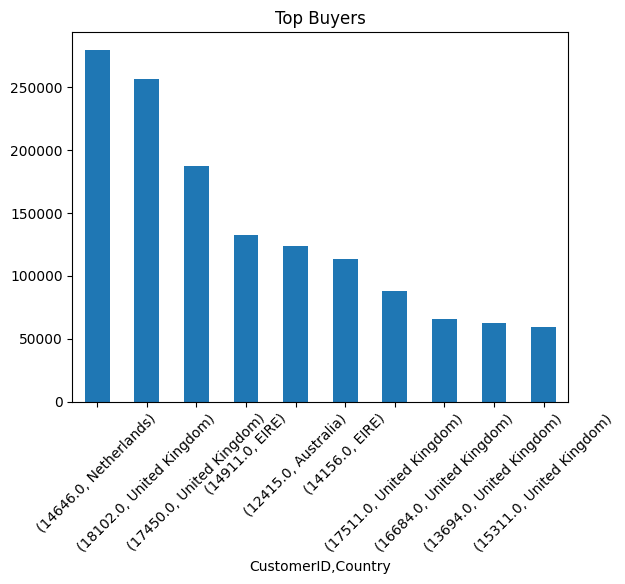

In [38]:
# Top buyers
top_buyers = (
    df_copy.groupby(["CustomerID", "Country"])["TotalPrice"]
    .sum()
    .sort_values(ascending=False)
    .head(10))
top_buyers.plot(kind='bar')
plt.xticks(rotation=45)
plt.title("Top Buyers")
plt.show()


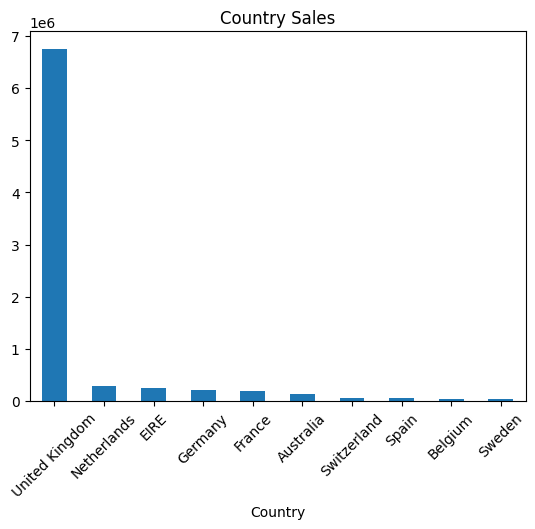

In [39]:
# country sale 
country_sales = df_copy.groupby("Country")["TotalPrice"].sum().sort_values(ascending=False).head(10)

country_sales.plot(kind='bar')

plt.title("Country Sales")
plt.xticks(rotation=45)
plt.show()


# RFM

In [40]:
df_copy['InvoiceDate'] = pd.to_datetime(df_copy['InvoiceDate'])


In [41]:
df_copy['InvoiceDate'].dtype

dtype('<M8[ns]')

In [42]:
snapshot_date = df_copy['InvoiceDate'].max() + pd.Timedelta(days=1)         

In [43]:
rfm = df_copy.groupby("CustomerID").agg({
    'InvoiceDate': lambda x: (snapshot_date - x.max()).days,
    'InvoiceNo': 'count',
    'TotalPrice': 'sum'
})

In [44]:
rfm.columns = ['Recency', 'Frequency', 'Monetary']

# print(rfm.head())
rfm.head(3)

,Recency,Frequency,Monetary
CustomerID,,,
12346.0,326,2,0.00
12347.0,2,182,4310.00
12348.0,75,31,1797.24


In [45]:
rfm.describe()

,Recency,Frequency,Monetary
count,4372.000000,4372.000000,4372.000000
mean,92.047118,91.858188,1893.531433
std,100.765435,229.223566,8218.696204
min,1.000000,1.000000,-4287.630000
25%,17.000000,17.000000,291.795000
50%,50.000000,41.000000,644.070000
75%,143.000000,99.250000,1608.335000
max,374.000000,7812.000000,279489.020000


# Scaling

In [46]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
rfm_scaled = scaler.fit_transform(rfm)

# Elbow Method

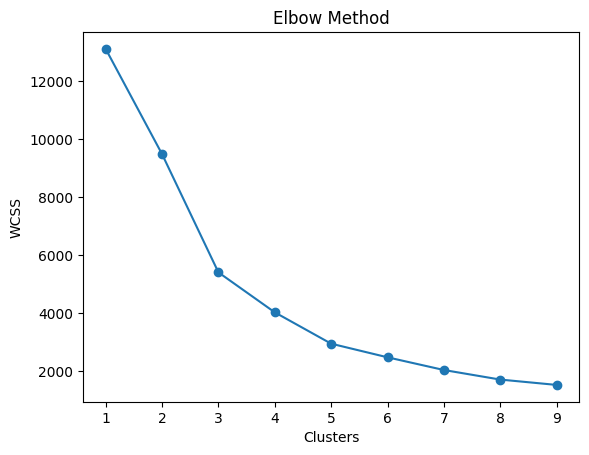

In [47]:
from sklearn.cluster import KMeans

wcss = []

for i in range(1, 10):
    km = KMeans(n_clusters=i, random_state=42)
    km.fit(rfm_scaled)
    wcss.append(km.inertia_)

plt.plot(range(1,10), wcss, marker="o")
plt.title("Elbow Method")
plt.xlabel("Clusters")
plt.ylabel("WCSS")
plt.show()

# KMeans model

In [48]:
kmeans = KMeans(n_clusters=4, random_state=42)
rfm["cluster"] = kmeans.fit_predict(rfm_scaled)

In [49]:
print(rfm["cluster"].value_counts())


cluster
0    3259
1    1102
2       6
3       5
Name: count, dtype: int64


In [50]:
print(rfm.groupby("cluster").mean())

            Recency    Frequency       Monetary
cluster                                        
0         40.060141   103.679963    1988.441284
1        246.659710    27.328494     462.094166
2          1.666667  4755.666667   54795.298333
3          9.000000  1012.200000  192037.944000


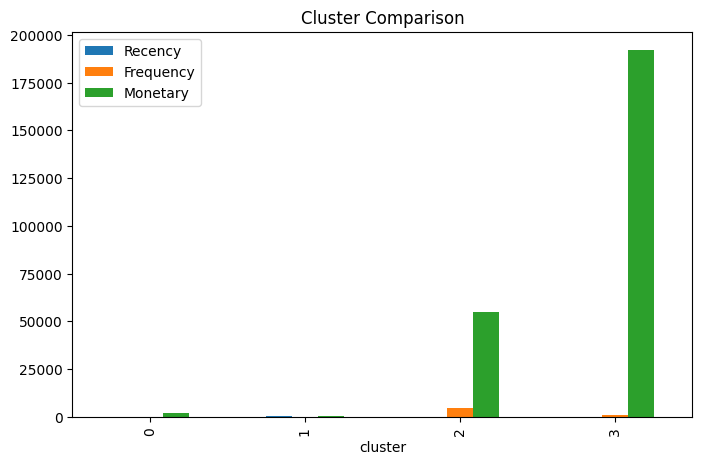

In [51]:
rfm.groupby("cluster").mean().plot(kind="bar", figsize=(8,5))

plt.title("Cluster Comparison")

plt.show()

In [52]:
# >>> ADDED (silhouette score)
from sklearn.metrics import silhouette_score

score = silhouette_score(rfm_scaled, rfm["cluster"])

print("Silhouette Score:", score)

Silhouette Score: 0.6000759146129651


# Cluster Visualization


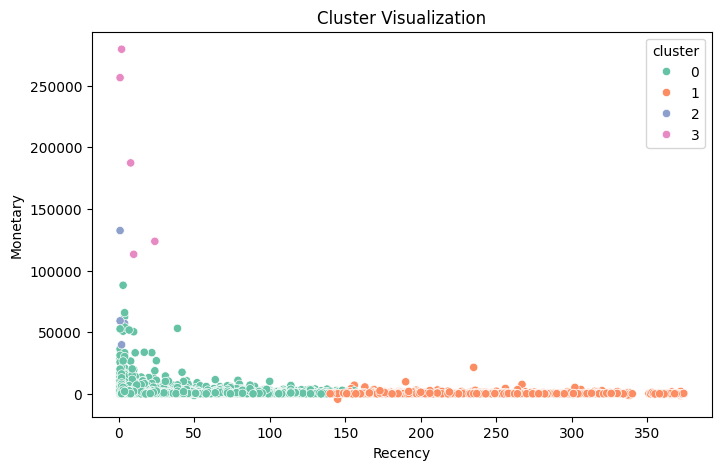

In [53]:
plt.figure(figsize=(8,5))
sns.scatterplot(
    x=rfm["Recency"],
    y=rfm["Monetary"],
    hue=rfm["cluster"],
    palette="Set2"
)

plt.title("Cluster Visualization")
plt.show()

# Give Cluster Names


In [54]:
cluster_map = {
    0: "Regular",
    1: "Inactive",
    2: "VIP",
    3: "Super VIP"
}

rfm["Segment"] = rfm["cluster"].map(cluster_map)

rfm.head()

,Recency,Frequency,Monetary,cluster,Segment
CustomerID,,,,,
12346.0,326,2,0.00,1,Inactive
12347.0,2,182,4310.00,0,Regular
12348.0,75,31,1797.24,0,Regular
12349.0,19,73,1757.55,0,Regular
12350.0,310,17,334.40,1,Inactive


# Merge with original data


In [55]:
rfm_reset = rfm.reset_index()
df_cluster = df_copy.merge(rfm_reset, on="CustomerID")
df_cluster.head(4)

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,TotalPrice,Recency,Frequency,Monetary,cluster,Segment
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,15.30,302,309,5303.48,1,Inactive
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34,302,309,5303.48,1,Inactive
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,22.00,302,309,5303.48,1,Inactive
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34,302,309,5303.48,1,Inactive


In [56]:
# top 5 products from each cluster
for i in range(4):

    top_desc_cluster = (df_cluster[df_cluster["cluster"] == i]["Description"].value_counts().head(5))

    print(f"\nTop products in cluster {i}")
    print(top_desc_cluster)


Top products in cluster 0
Description
WHITE HANGING HEART T-LIGHT HOLDER    1728
REGENCY CAKESTAND 3 TIER              1567
JUMBO BAG RED RETROSPOT               1486
ASSORTED COLOUR BIRD ORNAMENT         1252
PARTY BUNTING                         1207
Name: count, dtype: int64

Top products in cluster 1
Description
WHITE HANGING HEART T-LIGHT HOLDER    236
REGENCY CAKESTAND 3 TIER              213
PARTY BUNTING                         147
ASSORTED COLOUR BIRD ORNAMENT         131
JAM MAKING SET WITH JARS              120
Name: count, dtype: int64

Top products in cluster 2
Description
CHILLI LIGHTS               90
REGENCY CAKESTAND 3 TIER    89
CARRIAGE                    85
JUMBO BAG RED RETROSPOT     80
GUMBALL COAT RACK           76
Name: count, dtype: int64

Top products in cluster 3
Description
SPACEBOY LUNCH BOX                     35
DOLLY GIRL LUNCH BOX                   31
ROUND SNACK BOXES SET OF4 WOODLAND     29
REGENCY CAKESTAND 3 TIER               25
JAM MAKING SET WIT

# Top 10 products from all cluster combine 


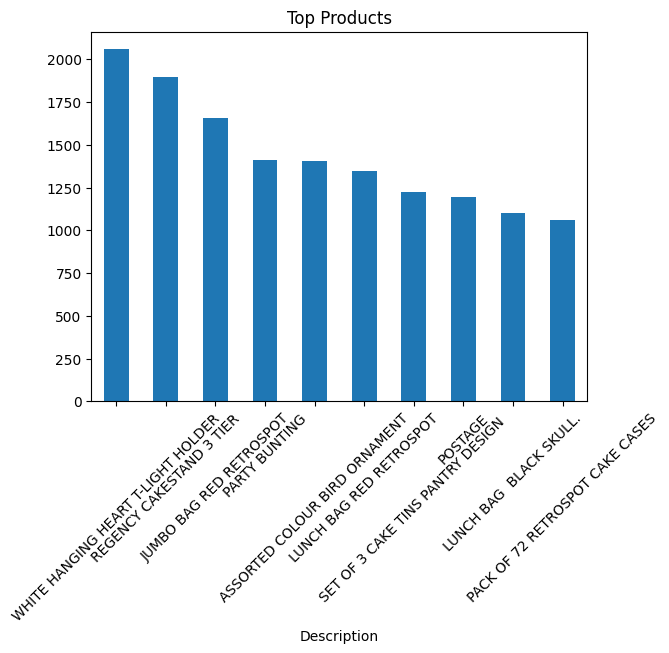

In [57]:
top_desc = df_cluster["Description"].value_counts().head(10)

top_desc.plot(kind="bar")
plt.title("Top Products")
plt.xticks(rotation=45)
plt.show()

# Save output

In [ ]:
# save
rfm.to_csv("../output/rfm_clusters.csv")
df_cluster.to_csv("../output/customer_segments.csv")

print("Saved")